# Gemma 4 12B Vision - FLN Image Analyzer (Colab)

**Setup:** Runtime → Change runtime type → **T4 GPU**  
**Secrets:** Add **HF_TOKEN** in the key icon (left sidebar)  
**Run:** Runtime → Run all

Upload one image in cell 4 to test the model.

In [ ]:
# @title 0. Free up disk space
import os, shutil

print("Freeing up space...")
!df -h /content

for item in os.listdir("/content"):
    path = os.path.join("/content", item)
    if item == "drive":
        continue
    try:
        if os.path.isfile(path) or os.path.islink(path):
            os.unlink(path)
        else:
            shutil.rmtree(path)
        print("Deleted:", path)
    except Exception as e:
        print("Failed:", path, e)

print("Cleanup complete.")
!rm -rf ~/.cache/pip
!df -h
print("Ready")

Freeing up space...
Filesystem      Size  Used Avail Use% Mounted on
overlay         113G   48G   66G  42% /
Deleted: /content/.config
Deleted: /content/Screenshot 2026-06-18 124617.png
Deleted: /content/sample_data
Cleanup complete.
Filesystem      Size  Used Avail Use% Mounted on
overlay         113G   48G   66G  42% /
tmpfs            64M     0   64M   0% /dev
shm             5.7G     0  5.7G   0% /dev/shm
/dev/root       2.0G  1.3G  696M  65% /usr/sbin/docker-init
/dev/sda1       119G   52G   67G  44% /opt/bin/.nvidia
tmpfs           6.4G   64K  6.4G   1% /var/colab
tmpfs           6.4G     0  6.4G   0% /proc/acpi
tmpfs           6.4G     0  6.4G   0% /proc/scsi
tmpfs           6.4G     0  6.4G   0% /sys/firmware
Ready


In [ ]:
# @title 1. Mount Drive
from google.colab import drive
import os, re, json, time, sys

drive.mount('/content/drive')

DRIVE_FOLDER = "/content/drive/MyDrive/FLN_Analysis"
os.makedirs(DRIVE_FOLDER, exist_ok=True)
print(f"Drive folder: {DRIVE_FOLDER}")

Mounted at /content/drive
Drive folder: /content/drive/MyDrive/FLN_Analysis


In [ ]:
# @title 2. Hugging Face Login
from huggingface_hub import login
from google.colab import userdata

token = userdata.get("HF_TOKEN")

if not token:
    raise ValueError("HF_TOKEN not found in Colab Secrets (add via key icon)")

login(token)
print("\u2705 Hugging Face login successful")

✅ Hugging Face login successful


In [ ]:
# @title 3. Install & Load Gemma 4 12B (Unsloth GGUF + Gemma4ChatHandler)
import torch
cuda_ver = torch.version.cuda
cuda_wheel = f"cu{cuda_ver.replace('.', '')}" if cuda_ver else "cu124"
if cuda_wheel not in ("cu121", "cu122", "cu123", "cu124", "cu125"):
    cuda_wheel = "cu124"
print(f"CUDA {cuda_ver} → using {cuda_wheel} pre-built wheel")
print("Step 1/3: Installing llama-cpp-python with CUDA (pre-built, ~30s)...")
sys.stdout.flush()
!pip install llama-cpp-python --extra-index-url https://abetlen.github.io/llama-cpp-python/whl/{cuda_wheel} --force-reinstall --no-cache-dir -q
print("Install OK")
sys.stdout.flush()

from llama_cpp import Llama
from llama_cpp.llama_chat_format import Gemma4ChatHandler

REPO = "unsloth/gemma-4-12b-it-GGUF"
MODEL_FILE = "gemma-4-12b-it-UD-Q5_K_XL.gguf"
MMPROJ_FILE = "mmproj-F16.gguf"

print("Step 2/3: Loading mmproj via Gemma4ChatHandler...")
sys.stdout.flush()
chat_handler = Gemma4ChatHandler.from_pretrained(
    repo_id=REPO,
    filename=MMPROJ_FILE,
    verbose=False,
)
print("  Chat handler OK")

print("Step 3/3: Downloading & loading model (~8.6 GB, ~6 min)...")
sys.stdout.flush()
start = time.time()
llm = Llama.from_pretrained(
    repo_id=REPO,
    filename=MODEL_FILE,
    chat_handler=chat_handler,
    n_gpu_layers=-1,
    n_ctx=8192,
    flash_attn=True,
    verbose=False,
)

t = (time.time()-start)/60
print(f"\nLoaded Gemma 4 12B in {t:.1f} min")

CUDA 12.8 → using cu124 pre-built wheel
Step 1/3: Installing llama-cpp-python with CUDA (pre-built, ~30s)...
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.8/1.8 GB 38.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 45.5/45.5 kB 269.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 134.9/134.9 kB 323.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 16.7/16.7 MB 394.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.6/44.6 kB 273.7 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
numba 0.60.0 requires numpy<2.1,>=1.22, but you have numpy 2.5.0 which is incompatible.
Install OK
Step 2/3: Loading mmproj via Gemma4ChatHandler...


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_validators.py:205: UserWarning: The `local_dir_use_symlinks` argument is deprecated and ignored in `hf_hub_download`. Downloading to a local directory does not use symlinks anymore.
  warnings.warn(


./mmproj-F16.gguf:   0%|          | 0.00/175M [00:00<?, ?B/s]

  Chat handler OK
Step 3/3: Downloading & loading model (~8.6 GB, ~6 min)...


./gemma-4-12b-it-UD-Q5_K_XL.gguf:   0%|          | 0.00/8.61G [00:00<?, ?B/s]

llama_context: n_ctx_seq (8192) < n_ctx_train (262144) -- the full capacity of the model will not be utilized
llama_kv_cache_iswa: using full-size SWA cache (ref: https://github.com/ggml-org/llama.cpp/pull/13194#issuecomment-2868343055)



Loaded Gemma 4 12B in 6.3 min


Select ONE image to analyze...


Saving Screenshot 2026-06-18 124617.png to Screenshot 2026-06-18 124617.png
Uploaded: Screenshot 2026-06-18 124617.png (74271 bytes)


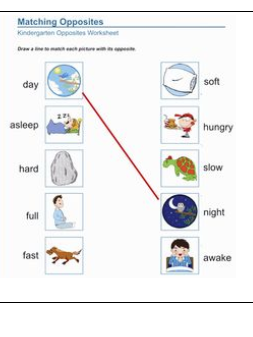

MIME: image/png  |  Base64: 99028 bytes
Analyzing...

RAW MODEL OUTPUT:
```json
{
  "question_heading": "Draw a line to match each picture with its opposite.",
  "question_type": "Matching",
  "learning_outcome": "Identifying and understanding basic antonyms (opposites) through visual and textual cues.",
  "student_action": "Draw lines to match",
  "answer_format": "match",
  "visual_elements": "Two columns of images and words. Left column: day (sun), asleep (sleeping person), hard (rock), full (glass of water), fast (running animal). Right column: soft (pillow), hungry (person with food), slow (snail), night (moon/stars), awake (person sitting up). A red example line connects 'day' to 'night'.",
  "number_range": "none",
  "has_example": true,
  "worksheet_type": "literacy",
  "difficulty": "easy",
  "skills": [
    "Vocabulary building",
    "Antonym recognition",
    "Visual-spatial matching"
  ],
  "all_text_detected": "Matching Opposites Kindergarten Opposites Worksheet Draw a lin

In [ ]:
# @title 4. Upload & analyze ONE image
import base64, mimetypes, json, re
from google.colab import files
from IPython.display import display, Image as IPyImage

print("Select ONE image to analyze...")
uploaded = files.upload()
if not uploaded:
    raise SystemExit("No file uploaded")

img_name = list(uploaded.keys())[0]
img_data = uploaded[img_name]
img_path = f"/content/{img_name}"
with open(img_path, "wb") as f:
    f.write(img_data)

print(f"Uploaded: {img_name} ({len(img_data)} bytes)")
display(IPyImage(img_path))

SYSTEM_PROMPT = """You are analyzing an FLN (Foundational Literacy and Numeracy) worksheet for children ages 3-7.
Examine the COMPLETE image and extract ALL possible information.

Respond ONLY with valid JSON (no markdown, no code fences):
{
  "question_heading": "The exact instruction text shown on the worksheet (e.g., 'Count and write the number', 'Match the fruits', 'Solve the addition problems'). Be precise.",
  "question_type": "One of: Counting|Number Recognition|Missing Numbers|Ascending Order|Descending Order|Addition|Subtraction|Shapes|Patterns|Matching|Classification|Logical Reasoning|Tracing|Comparison|Skip Counting|Finger Counting|Review Assessment|Coloring|Writing Practice|Word Problem",
  "learning_outcome": "The specific educational skill being taught (e.g., 'Counting objects up to 10', 'Basic addition with visual aids', 'Number sequencing 1-30')",
  "student_action": "What the student physically does (e.g., 'Draw lines to match', 'Write the number in the blank', 'Circle the correct answer', 'Color the shapes', 'Cut and paste', 'Trace the dotted lines')",
  "answer_format": "How the answer is given (e.g., 'fill_in_blank', 'circle', 'match', 'draw', 'color', 'trace', 'cut_paste', 'write_number')",
  "visual_elements": "What visual elements are in the image (e.g., 'fruits to count, numbered boxes, matching lines', 'grid with numbers 1-30, some missing', 'dots to connect, numbered 1-25')",
  "number_range": "The range of numbers used (e.g., '1-10', '1-30', '1-50', '1-20', 'none')",
  "has_example": true or false,
  "worksheet_type": "One of: numeracy|literacy|fine_motor|mixed",
  "difficulty": "One of: easy|medium|hard",
  "skills": ["skill1", "skill2"],
  "all_text_detected": "All readable text found in the image, exactly as it appears",
  "confidence_score": 0-100,
  "reasoning": "Detailed explanation of visual evidence that led to your conclusions"
}"""

# Step 1: Encode image
mime = mimetypes.guess_type(img_path)[0] or "image/png"
with open(img_path, "rb") as f:
    b64 = base64.b64encode(f.read()).decode("utf-8")
print(f"MIME: {mime}  |  Base64: {len(b64)} bytes")

# Step 2: Get raw model response
print("Analyzing...")
resp = llm.create_chat_completion(
    messages=[{"role": "user", "content": [
        {"type": "image_url", "image_url": {"url": f"data:{mime};base64,{b64}"}},
        {"type": "text", "text": SYSTEM_PROMPT + "\n\nWhat is this worksheet asking?"},
    ]}],
    max_tokens=4096, temperature=0.1,
)
raw = resp["choices"][0]["message"]["content"]

print(f"\n{'='*60}")
print("RAW MODEL OUTPUT:")
print(f"{'='*60}")
print(raw)
print(f"{'='*60}\n")

# Step 3: Try to parse as JSON
cleaned = re.sub(r'<think>.*?</think>', '', raw, flags=re.DOTALL).strip()
cleaned = re.sub(r'```json\s*|```\s*', '', cleaned).strip()
try:
    parsed = json.loads(cleaned)
    print("PARSED JSON:")
    print(json.dumps(parsed, indent=2))
except json.JSONDecodeError as e:
    print(f"JSON PARSE FAILED: {e}")
    print("First 500 chars of raw output above ^")